<a href="https://colab.research.google.com/github/abhi01-sys/ML--Journey/blob/main/Perceptron_Trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [44]:
X,y = make_classification(n_samples = 100 , n_features=2, n_informative=1, n_redundant=0,n_classes = 2,n_clusters_per_class=1
                          ,random_state=41,hypercube=False,class_sep=30)

In [45]:
X

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163],
       [-4.2289949 ,  0.15599044],
       [-5.18865382,  1.07782053],
       [ 0.7096287 ,  0.80626713],
       [ 0.06531501,  0.74859527],
       [-5.3563263 ,  0.75152794],
       [-5.17487315, -0.90114581],
       [-5.17644221, -0.1815243 ],
       [ 0.60202649, -2.98092432],
       [ 1.42960231,  1.20500136],
       [-5.22359581,  0.78302407],
       [ 1.01127528,  0.42968688],
       [ 0.48288133, -0.73229726],
       [-5.27614308, -0.83930476],
       [ 0.44163889,  0.83727062],
       [-5.167179  , -0.10255323],
       [-5.67316396,  0.65867001],
       [-5.4617787 ,  0.92649819],
       [-4.71348919,  0.10216193],
       [ 2.2344006 ,  0.46886454],
       [-4.61308761,  0.45432938],
       [ 1.2379403 ,  1.8613386 ],
       [-5.18419324, -0.79255991],
       [-4.43807529, -1.0004391 ],
       [-5.79725951,

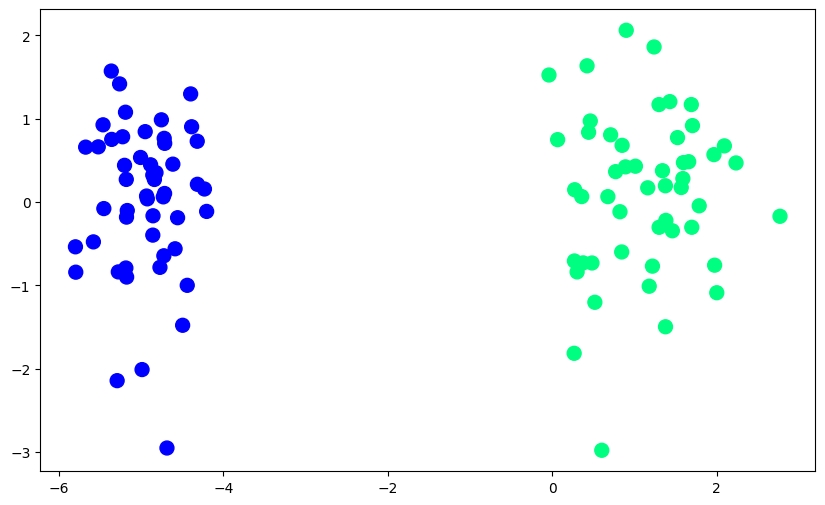

In [46]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c = y,cmap = 'winter',s = 100)
plt.show()

In [47]:
np.insert(X,0,1,axis = 1)

array([[ 1.        ,  0.82321545, -0.11697552],
       [ 1.        ,  0.37514771, -0.73115232],
       [ 1.        ,  0.26947761, -0.7081059 ],
       [ 1.        , -4.98744874, -2.01199214],
       [ 1.        ,  0.4231285 ,  1.63493163],
       [ 1.        , -4.2289949 ,  0.15599044],
       [ 1.        , -5.18865382,  1.07782053],
       [ 1.        ,  0.7096287 ,  0.80626713],
       [ 1.        ,  0.06531501,  0.74859527],
       [ 1.        , -5.3563263 ,  0.75152794],
       [ 1.        , -5.17487315, -0.90114581],
       [ 1.        , -5.17644221, -0.1815243 ],
       [ 1.        ,  0.60202649, -2.98092432],
       [ 1.        ,  1.42960231,  1.20500136],
       [ 1.        , -5.22359581,  0.78302407],
       [ 1.        ,  1.01127528,  0.42968688],
       [ 1.        ,  0.48288133, -0.73229726],
       [ 1.        , -5.27614308, -0.83930476],
       [ 1.        ,  0.44163889,  0.83727062],
       [ 1.        , -5.167179  , -0.10255323],
       [ 1.        , -5.67316396,  0.658

In [48]:
def step(x):
  if x>0:
    return 1
  else:
    return 0

In [49]:
def perceptron(X,y):
  lr = 0.1
  X = np.insert(X,0,1,axis = 1)
  weights = np.ones(X.shape[1])

  for i in range(1000):
    j = np.random.randint(0,X.shape[0])
    y_pred = step(np.dot(X[j],weights))
    weights = weights + lr*(y[j]-y_pred)*X[j]

  return weights[0],weights[1:]

In [50]:
intercept_,coef_ = perceptron(X,y)

In [51]:
intercept_

np.float64(1.2000000000000002)

In [52]:
coef_

array([1.08682872, 0.52024363])

In [53]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [54]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

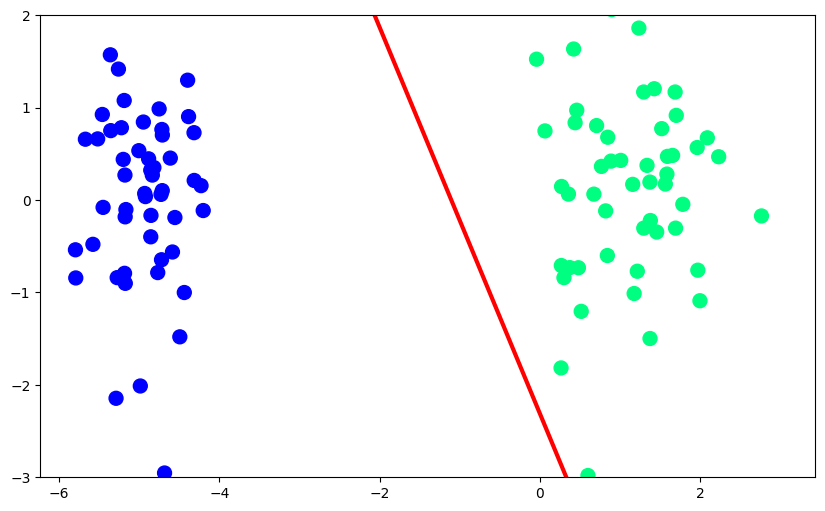

In [55]:
plt.figure(figsize = (10,6))
plt.plot(x_input,y_input,color='red',linewidth = 3)
plt.scatter(X[:,0],X[:,1],c=y,cmap = 'winter',s=100)
plt.ylim(-3,2)

In [56]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()

In [57]:
lor.fit(X,y)

LogisticRegression()

In [58]:
m = lor.coef_[0][0]/lor.coef_[0][1]
b = lor.intercept_[0]/lor.coef_[0][1]


In [59]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

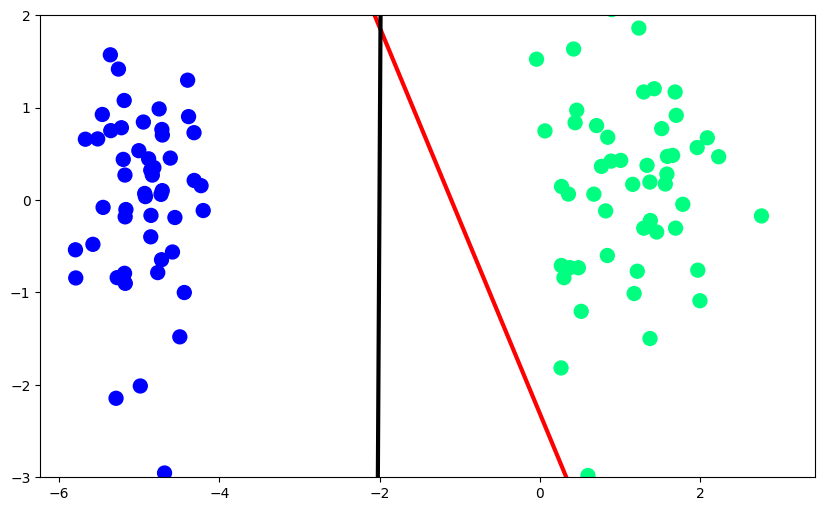

In [60]:
#class_sep = 10/20/30 : clearly shows the problem with perceptron trick

plt.figure(figsize = (10,6))
plt.plot(x_input,y_input,color='red',linewidth = 3)
plt.plot(x_input1,y_input1,color='black',linewidth = 3)
plt.scatter(X[:,0],X[:,1],c=y,cmap = 'winter',s=100)
plt.ylim(-3,2)